### Group Members:

- Daria Stetsenko, 23-740-806
- Name, matriculation number
- Name, matriculation number

# Assignment 1: Universal Function Approximator


The goal of this exercise is to compare three different neural network architectures and analyze their capacity for function approximation:

1. $N_0$: One-layer network (linear transformation only)
2. $N_1$: One-layer network with non-linear activation function
3. $N_2$: Two-layer network (hidden layer with non-linear activation function)

They will be trained via gradient descent with weight decay. 
To show the flexibility of the approach, three different functions will be approximated:
1. $X_0: t = \sin(2x)$ for $x\in[-2,2]$
2. $X_1: t = e^{-x^2}$ for $x\in[-3,3]$
3. $X_2: t = -x^5 - 3x^4 + 11x^3 +27x^2 - 10x - 32$ for $x\in[-4.5,3.5]$

In the theoretical section, the networks will be designed, and the necessary derivatives will be computed by hand.

In the coding section, we will: 

- implement the networks and their gradients,
- generate target data for three different functions, 
- apply the training procedure to the data, and 
- plot the resulting approximated function together with the data samples.

## Section 1: Theoretical Questions

### Network Design

#### Task 1.1: Network Structure

Given input $\vec x = (1, x)^T$, define three neural networks ($N_0$, $N_1$, $N_2$) mathematically, to reach output $y$. Use $g()$ to represent the activation function.

Explain how their structures differ and analyze their function approximation capabilities.

--- 
Note:

For one-layer networks, define parameter $\Theta=\vec w \in\mathbb R^{D+1}$

For two-layer network, define parameters $\Theta=(\mathbf W^{(1)},\vec w^{(2)})$ that are split into $\mathbf W^{(1)}\in\mathbb R^{K\times {(D+1)}}$ for the first layer and $\vec w^{(2)}\in\mathbb R^{K+1}$ for the second layer

$N_0$: $y = \vec w^T \vec x$

$N_1$: $y = \vec w^T g(\vec x)$

$N_2$: $y = \vec w^{(2)T} g(\mathbf W^{(1)} \vec x)$

#### Task 1.2: Network Comparison

Can the one-layer network approximate all three functions well? 
Why or why not?

What advantages does the two-layer network have compared to a one-layer network?

How can we determine the appropriate number of hidden neurons?
When looking at the example plots in the OLAT, how many hidden neurons do we need in order to approximate the functions? 
Is there any difference between the three target functions?


1. The one-layer network can only represent linear functions, so it cannot approximate non-linear functions like $\sin(2x)$ or $e^{-x^2}$ well. It may be able to approximate the polynomial function to some extent, but it will not capture the complexity of the function accurately.
2. The two-layer network can capture non-linear relationships due to the presence of the hidden layer and the activation function. This allows it to approximate a wider variety of functions, including those that are non-linear.
3. The appropriate number of hidden neurons can be determined by counting the number of turning points (extrema) in the target function. Each $\tanh$ hidden neuron contributes roughly one sigmoid-shaped transition, so the number of extrema gives a good lower bound on the required neurons.
4. Based on the example plots:
   - $X_0 = \sin(2x)$: ~2 full oscillations on $[-2,2]$ with 4 extrema → **K = 4** hidden neurons
   - $X_1 = e^{-x^2}$: a single bell-shaped peak with 2 transitions → **K = 3** hidden neurons
   - $X_2$ (degree-5 polynomial): multiple turning points and a large output range → **K = 6** hidden neurons
5. Yes, the three functions differ in complexity. The Gaussian ($X_1$) is the simplest (fewest neurons needed), the sine ($X_0$) is moderate, and the polynomial ($X_2$) is the most complex due to its higher number of turning points and large output range, requiring the most hidden neurons.

#### Task 1.3: Network Performance

If the network struggles to approximate a function well, what are some possible reasons?

How can we improve the network's performance?


##### Reasons
- Insufficient model capacity (e.g., too few hidden neurons)
- Inappropriate choice of activation function
- Poor initialization of weights
- Inadequate training data or overfitting
- Suboptimal learning rate or optimization algorithm

##### Solutions
- Increase the number of hidden neurons or layers
- Experiment with different activation functions
- Use better weight initialization techniques
- Augment the training data or apply regularization to prevent overfitting
- Tune the learning rate and try different optimization algorithms (e.g., Adam, RMSprop)

### Derivatives

#### Task 1.4: Activation Function

Given the hyperbolic tangent ($\tanh$) activation function as:

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

Prove:

$$\frac{\partial}{\partial x} \tanh(x) = 1 - \tanh^2(x)$$

Hint: Apply the derivative rules as defined in the Lecture:
* Quotient rule
* Sum rule
* Exponential rule

Also, avoid factoring out parentheses.

Let $f(x) = e^x - e^{-x}$ and $g(x) = e^x + e^{-x}$, so that $\tanh(x) = \frac{f(x)}{g(x)}$.

**Step 1: Compute $f'(x)$ and $g'(x)$ using the sum rule and exponential rule**

$$f'(x) = \frac{\partial}{\partial x}(e^x - e^{-x}) = e^x - (-1)e^{-x} = e^x + e^{-x}$$

$$g'(x) = \frac{\partial}{\partial x}(e^x + e^{-x}) = e^x + (-1)e^{-x} = e^x - e^{-x}$$

**Step 2: Apply the quotient rule**

$$\frac{\partial}{\partial x}\tanh(x) = \frac{f'(x)g(x) - f(x)g'(x)}{g(x)^2}$$

$$= \frac{(e^x + e^{-x})(e^x + e^{-x}) - (e^x - e^{-x})(e^x - e^{-x})}{(e^x + e^{-x})^2}$$

$$= \frac{(e^x + e^{-x})^2 - (e^x - e^{-x})^2}{(e^x + e^{-x})^2}$$

$$= \frac{(e^x + e^{-x})^2}{(e^x + e^{-x})^2} - \frac{(e^x - e^{-x})^2}{(e^x + e^{-x})^2}$$

$$= 1 - \left(\frac{e^x - e^{-x}}{e^x + e^{-x}}\right)^2 = 1 - \tanh^2(x) \qquad \blacksquare$$

#### Task 1.5: Weight Decay

Consider a loss function with L2 regularization (weight decay):
$$
\mathcal J'_\Theta = \mathcal J_\Theta + \frac{\lambda}{2} \|\Theta\|^2
$$

Expecting the gradient of the network $\nabla \mathcal J_\Theta$ to be given, compute the derivative of $\mathcal J'$ with respect to all $\Theta_i$: $$\biggl[\frac{\partial}{\partial \Theta_i} \mathcal J'_\Theta\biggr]_i$$

Since $\mathcal J'_\Theta = \mathcal J_\Theta + \frac{\lambda}{2} \|\Theta\|^2 = \mathcal J_\Theta + \frac{\lambda}{2} \sum_j \Theta_j^2$, we differentiate with respect to $\Theta_i$:

$$\frac{\partial}{\partial \Theta_i} \mathcal J'_\Theta = \frac{\partial}{\partial \Theta_i} \mathcal J_\Theta + \frac{\lambda}{2} \frac{\partial}{\partial \Theta_i} \sum_j \Theta_j^2 = \frac{\partial}{\partial \Theta_i} \mathcal J_\Theta + \lambda \Theta_i$$

In vector form:

$$\nabla_\Theta \mathcal J'_\Theta = \nabla_\Theta \mathcal J_\Theta + \lambda \Theta$$

#### Task 1.6

How large should an appropriate weight decay parameter $\lambda$ as shown in Task 1.5 be? What would happen if $\lambda$ is set too high or too low?

The weight decay parameter $\lambda$ should be **small** (e.g., $\lambda \in [10^{-4}, 10^{-1}]$), chosen so that regularization gently constrains the weights without dominating the loss.

- **$\lambda$ too high:** The penalty term $\lambda \Theta_i$ dominates the gradient. The weights are driven toward zero, causing the network to **underfit** — it loses capacity and cannot approximate the target function.
- **$\lambda$ too low (or zero):** The regularization has little effect. The network may **overfit** the training data, memorizing noise rather than learning the underlying function, leading to poor generalization.

In practice, $\lambda$ is treated as a hyperparameter and tuned via experimentation (e.g., cross-validation).

## Section 2: Coding

**<font color='red' size='5'>This section has to be submitted by 11:59 p.m. on Wednesday, March 11th, to be graded.</font>**



### Network Implementation
#### Task 2.1

Recall that for one-layer networks, we define parameter $\Theta=\vec w \in\mathbb R^{D+1}$, and for a two-layer network, we define parameters $\Theta=(\mathbf W^{(1)}\in\mathbb R^{K\times {(D+1)}},\vec w^{(2)}\in\mathbb R^{K+1})$.

- D: The dimension of the input. In this assignment, $D = 1$ since there is only one input.
- K: The number of neurons in the hidden layer of the two-layer network ($N_2$)

Implement a function that returns the network output for a given input $\vec x$, model_type ($N_0$, $N_1$, or $N_2$) and parameters $\Theta$. 
Remember that the input of the function $\vec x = (1, x)^T$.

---
Note:

1. Use the `numpy` to implement the $\tanh$ function.
2. Use `numpy.concatenate` or `numpy.insert` to prepend $h_0$.
3. Make use of `numpy.dot` to compute matrix-vector and vector-vector products.

In [1]:
import numpy

def network(x, model_type, Theta):
    """
    Compute the output of a neural network model.

    Args:
        x: Input vector (1, x) including bias.
        model_type: Type of model (0, 1, or 2).
        Theta: Tuple of network parameters (W1, w2).

    Returns:
        y: Network output.
        h: Hidden layer output, or None.
    """

    W1, w2 = Theta # w2 is None if model_type is 1 or 2

    if model_type == 0:
        # One-layer network (Linear Model)
        y = numpy.dot(W1, x) # Linear transformation
        return y, None # To make this consistent when model_type is 3

    elif model_type == 1:
        # One-layer network with tanh activation
        y = numpy.tanh(numpy.dot(W1, x))
        return y, None # To make this consistent when model_type is 3

    elif model_type == 2:
        # Two-layer network with tanh activation
        a_ = numpy.dot(W1, x) # Linear transformation for hidden layer
        h_ = numpy.tanh(a_) # Activation for hidden layer
        h = numpy.concatenate((h_, [1])) # Add bias to hidden layer output
        y = numpy.dot(w2, h) # Linear transformation for output layer
        return y, h

#### Test 1: Sanity Check

We select a specific number of hidden neurons and create the weights accordingly, using all zeros in the first layer and all ones in the second. The test case below ensures that the function from Task 1 actually returns $11$ for those weights.

In [2]:
# Define test parameters
K_ = 20
D_ = 1
Theta_one_layer = [numpy.ones(D_+1),None]
Theta_two_layer = [numpy.zeros((K_, D_+1)), numpy.ones(K_+1)]
x = numpy.random.rand(D_+1)

# Sanity check for N1
y1, _ = network(x, 0, Theta_one_layer)
assert abs(numpy.sum(x) - y1) < 1e-6
print("N1 test passed.")

# Sanity check for N2
y2, _ = network(x, 1, Theta_one_layer)
assert abs(numpy.tanh(numpy.sum(x)) - y2) < 1e-6
print("N2 test passed.")

# Sanity check for N3
y3, _ = network(x, 2, Theta_two_layer)
assert abs(1.0 - y3) < 1e-6
print("N3 test passed.")

N1 test passed.
N2 test passed.
N3 test passed.


### Gradient Implementation

#### Task 2.2: Gradient Computation


Implementation of a function that returns the gradient as defined for a given dataset $X=\{(\vec x^{[n]}, t^{[n]})\}$, model_type, parameters $\Theta$, and the $\lambda$ parameter for weight decay.

---
Note:

You should make sure that both parts of the gradient are computed for $N_2$ (since $\Theta=(\mathbf W^{(1)},\vec w^{(2)})$ here).

This is a very slow implementation. We will see how to speed this up in the next lecture.

In [3]:
def compute_gradient(X, model_type, Theta, lambda_=1.):
    """
    Compute the gradient of the loss function with respect to the weights for each model type.

    Args:
        X: Dataset containing input-target pairs (x, t).
        model_type: Type of model (0, 1, or 2).
        Theta: Network parameters (W1, w2).
        lambda_: Weight decay parameter. Default is 1.0.

    Returns:
        Gradients with respect to W1 and w2. For model_type 1 and 2, w2 is None.
    """

    # split parameters for easier handling
    W1, w2 = Theta # w2 is None if model_type is 1 or 2

    # define gradient with respect to both parameters
    dW1 = numpy.zeros_like(W1)
    dw2 = numpy.zeros_like(w2) if w2 is not None else None

    # iterate over dataset
    for x, t in X:
        # get network output
        y, h = network(x, model_type, Theta)

        # compute and aggregate the gradient, based on the network type
        if model_type == 0:
            dW1 += 2 * (y - t) * x

        elif model_type == 1:
            dW1 += 2 * (y - t) * (1 - y**2) * x

        elif model_type == 2:
            # w2[:-1] * (1 - h[:-1]**2) are both (K,), element-wise product first
            delta = 2 * (y - t) * (w2[:-1] * (1 - h[:-1]**2))
            dW1 += delta[:, None] * x  # (K,1) * (D+1,) -> (K, D+1)
            dw2 += 2 * (y - t) * h

    # Add penalty term/weight decay
    dW1 += lambda_ * W1
    if dw2 is not None:
        dw2 += lambda_ * w2

    return dW1, dw2

#### Task 2.3: Gradient Descent

The procedure of gradient descent is the repeated application of two steps.

1. The gradient of loss $\nabla_{\Theta}\mathcal J^{L_2}$ is computed based on the current value of the parameters $\Theta$.
2. The weights are updated by moving a small step in the direction of the negative gradient:

$$
\begin{align}
    \Theta = \Theta - \eta \nabla_{\Theta}\mathcal J
\end{align}
$$

As a stopping criterion, we select the number of training epochs to be 10000.

Implementation of a function that performs gradient descent for a given dataset $X$, given initial parameters $\Theta$, a given learning rate $\eta$, model_type ($N_1$, $N_2$, or $N_3$), and $\lambda$ parameter for weight decay, and returns the optimized parameters $\Theta^*$.

In [4]:
def gradient_descent(X, model_type, Theta, eta, lambda_=1., epochs=10000):
    """
    Perform gradient decent for each model type.

    Args:
        X: Dataset containing input-target pairs (x, t).
        model_type: Type of model (0, 1, or 2).
        Theta: Network parameters (W1, w2).
        eta: Learning rate.
        lambda_: Weight decay parameter. Default is 1.0.
        epochs: The number of epochs to train for

    Returns:
        The optimized model parameters
    """

    # perform iterative gradient descent
    for _ in range(epochs):
        # compute the gradient
        dW1, dw2 = compute_gradient(X, model_type, Theta, lambda_)

        # update the parameters
        W1, w2 = Theta
        W1 -= eta * dW1
        if w2 is not None:
            w2 -= eta * dw2
        Theta = (W1, w2)

    # return optimized parameters
    return Theta

### Datasets

#### Task 2.4: Data Samples

In total, we will test our gradient descent function with three different datasets. Particularly, we approximate

1. $X_0: t = \sin(2x)$ for $x\in[-2,2]$
2. $X_1: t = e^{-x^2}$ for $x\in[-3,3]$
3. $X_2: t = -x^5 - 3x^4 + 11x^3 +27x^2 - 10x - 32$ for $x\in[-4.5,3.5]$

Generate dataset $X_0$ for $N=45$ samples randomly drawn from range $x\in[-2,2]$. 
Generate dataset $X_1$ for $N=15$ samples randomly drawn from range $x\in[-3,3]$. 
Generate dataset $X_2$ for $N=250$ samples randomly drawn from range $x\in[-4.5,3.5]$. 
Implement all three datasets as lists of tuples: $\{(\vec x^{[n]}, t^{[n]})\mid 1\leq n\leq N\}$

In [5]:
# X0: t = sin(2x) for x in [-2, 2], N=45
x_vals = numpy.random.uniform(-2, 2, 45)
X0 = [(numpy.array([1.0, x]), numpy.sin(2 * x)) for x in x_vals]

# X1: t = exp(-x^2) for x in [-3, 3], N=15
x_vals = numpy.random.uniform(-3, 3, 15)
X1 = [(numpy.array([1.0, x]), numpy.exp(-x**2)) for x in x_vals]

# X2: t = -x^5 - 3x^4 + 11x^3 + 27x^2 - 10x - 32 for x in [-4.5, 3.5], N=250
x_vals = numpy.random.uniform(-4.5, 3.5, 250)
X2 = [(numpy.array([1.0, x]), float(-x**5 - 3*x**4 + 11*x**3 + 27*x**2 - 10*x - 32)) for x in x_vals]

#### Test 2: Sanity Check

The test case below ensures that the elements of each generated dataset are tuples with two dimensions.
It does not test that the values are correct.

In [6]:
for i, X in enumerate((X0, X1, X2)):
    assert all(
        isinstance(x, (tuple, list)) and
        len(x) == 2 and
        isinstance(x[0], (tuple, list, numpy.ndarray)) and
        len(x[0]) == 2 and
        isinstance(x[1], (float, numpy.float32, numpy.float64))
        for x in X
    ), f"Test failed for dataset X{i}"

print('Test passed!')

Test passed!


### Function Approximation
Finally, we want to make use of our gradient descent implementation to approximate our functions. In order to see our success, we want to plot the functions together with the data.

#### Task 2.5: Define Hidden Neurons
How many hidden neurons will we need for $N_2$? Use the answers from Task 1.2.

In [7]:
# Define the number of neurons for each target function based on your discussion
K0 = 4
K1 = 3
K2 = 6

#### Task 2.6: Random Parameters

For each of the networks, randomly initialize the parameters $\Theta_0,\Theta_1,\Theta_2\in[-1,1]$ for each of the datasets.

For $N_2$, use the number of hidden neurons estimated in Task 1.2 and implemented in Task 2.5.

---
Note:

  1. You can use `numpy.random.uniform` to initialize the weights.
  2. Make sure that the weight matrices are instantiated in the correct dimensions.
  3. Theta should always have two elements. The second element can be `None` for one-layer networks.


In [8]:
D = 1

# Initialize weights for One-Layer Network (No Activation), once for each dataset
Thetas_N0 = [
    (numpy.random.uniform(-1, 1, D+1), None),
    (numpy.random.uniform(-1, 1, D+1), None),
    (numpy.random.uniform(-1, 1, D+1), None)
]

# Initialize weights for One-Layer Network (With Activation)
Thetas_N1 = [
    (numpy.random.uniform(-1, 1, D+1), None),
    (numpy.random.uniform(-1, 1, D+1), None),
    (numpy.random.uniform(-1, 1, D+1), None)
]

# Initialize weights for Two-Layer Network
Thetas_N2 = [
    (numpy.random.uniform(-1, 1, (K0, D+1)), numpy.random.uniform(-1, 1, K0+1)),
    (numpy.random.uniform(-1, 1, (K1, D+1)), numpy.random.uniform(-1, 1, K1+1)),
    (numpy.random.uniform(-1, 1, (K2, D+1)), numpy.random.uniform(-1, 1, K2+1))
]

#### Task 2.7: Run Gradient Descent

For each network, call gradient descent function from Task 2.3 using the datasets $X_0, X_1, X_2$, the according created parameters $\Theta_0,\Theta_1,\Theta_2$.
Store the resulting optimized weights $\Theta_0^*, \Theta_1^*, \Theta_2^*$.

Based on your chosen learning rates $\eta$ and weight decay parameter $\lambda$, you may need to optimize them for these functions. 
Do you see any differences? 
What are the best learning rates that you can find?

---
<span style="color:red">WARNING: Depending on the implementation, this might run for several minutes!</span>

---
Hints:

1. Start with $\eta=0.1$ and play around with the learning rate improve adaptation.
2. $\eta=0.1$ might be too large for $X_2$.

In [16]:
# Train all 3 model types on all 3 datasets (9 runs total)
datasets = [X0, X1, X2]
lambda_ = 0.001

# N0: one-layer linear network on each dataset
Thetas_N0_star = []
for i, X in enumerate(datasets):
    eta = 0.01 if i == 2 else 0.1
    Thetas_N0_star.append(gradient_descent(X, 0, Thetas_N0[i], eta, lambda_))
print("N0 done")

# N1: one-layer with tanh on each dataset
Thetas_N1_star = []
for i, X in enumerate(datasets):
    eta = 0.01 if i == 2 else 0.1
    Thetas_N1_star.append(gradient_descent(X, 1, Thetas_N1[i], eta, lambda_))
print("N1 done")

# N2: two-layer network on each dataset
Thetas_N2_star = []
for i, X in enumerate(datasets):
    eta = 0.001 if i == 2 else 0.01
    Thetas_N2_star.append(gradient_descent(X, 2, Thetas_N2[i], eta, lambda_))
print("N2 done")

N0 done
N1 done
N2 done


### Data and Function Plotting

### Task 2.8: Plotting Function

Implement a plotting function that takes a given dataset $X$, model_type, parameters $\Theta$, and a defined range $R=[\min,\max]$. 
Each data sample $(\vec x^{[n]}, t^{[n]})$ of the dataset is plotted as an ''x''. 
In order to plot the function that is approximated by the network, generate sufficient equally-spaced input values $x\in R$, compute the network output $y$ for these inputs, and plot them with a line.

---
Hints:

  1. The dataset $X$ is defined as above, a list of tuples $(\vec x, t)$.
  2. Each input in the dataset is defined as $\vec x = (1,x)^T$.
  3. Equidistant points can be obtained via `numpy.arange`.


In [17]:
from matplotlib import pyplot

def plot(X, model_type, Theta, R):
    """
    Plots the data and the network output into one plot

    Args:
        X: Dataset containing input-target pairs (x, t).
        model_type: Type of model (0, 1, or 2).
        Theta: Network parameters (W1, w2).
        R: The range for which we plot the model output
    """
    # first, plot data samples — x[1] is the actual input value, x[0] is bias=1
    pyplot.plot([s[0][1] for s in X], [s[1] for s in X], "rx", label="Data")

    # define equidistant points from min (R[0]) to max (R[1]) to evaluate the network
    x_vals = numpy.arange(R[0], R[1], 0.01)
    # compute the network outputs for these values
    y_vals = [network(numpy.array([1.0, xi]), model_type, Theta)[0] for xi in x_vals]
    # plot network approximation
    pyplot.plot(x_vals, y_vals, "k-", label="Network")
    pyplot.legend()

#### Task 2.9: Plot Three Functions for three datasets

For each of the datasets and for each network type including their according optimized parameters, call the plotting function from Task 2.8. 
Use range $R=[-3,3]$ for dataset $X_0$, range $R=[-4,4]$ for $X_1$, and range $R=[-6,5]$ for dataset $X_2$.

Note that the first element of range $R$ should be the lowest $x$-location, and the second element of $R$ the highest value for $x$.

Repeat for three networks.

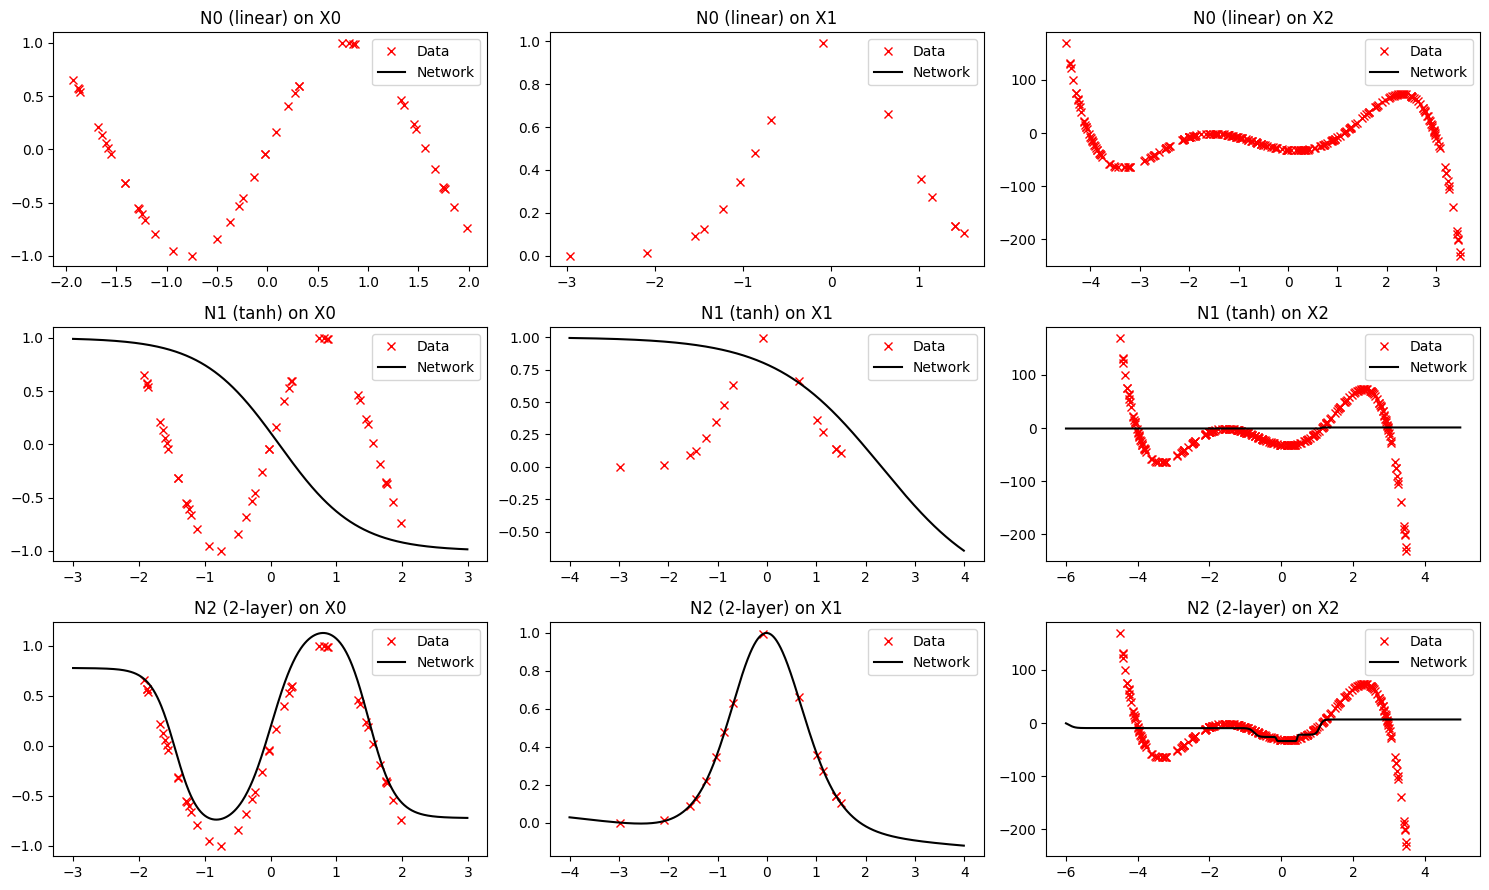

In [18]:
# create one large figure
figure = pyplot.figure(figsize=(15, 9))

# Ranges for each dataset
ranges = [[-3, 3], [-4, 4], [-6, 5]]
# Trained parameters: rows = model types, cols = datasets
all_Thetas = [Thetas_N0_star, Thetas_N1_star, Thetas_N2_star]
model_names = ["N0 (linear)", "N1 (tanh)", "N2 (2-layer)"]
dataset_names = ["X0", "X1", "X2"]

# iterate over the model types
for model_type in range(3):
    # iterate over the datasets
    for i, X in enumerate([X0, X1, X2]):
        # activate correct plot
        pyplot.subplot(3, 3, 3 * model_type + i + 1)
        # call the plot function with correct dataset, range, model type, and trained Theta
        plot(X, model_type, all_Thetas[model_type][i], R=ranges[i])
        pyplot.title(f"{model_names[model_type]} on {dataset_names[i]}")

pyplot.tight_layout()